In [ ]:
# Define the problem:
# Predict whether a passenger survived the Titanic disaster based on features.
objective = "Classification: Survived (Yes/No)"
success_criteria = "Accuracy > 80%"
constraints = "Limited features, missing values, imbalanced classes"
print("Objective:", objective)
print("Success Criteria:", success_criteria)
print("Constraints:", constraints)


In [ ]:
# Step2 Data Collection
import pandas as pd                 # Load dataset (Titanic dataset from seaborn or CSV)
import seaborn as sns
df = sns.load_dataset("titanic")
print("Data shape:", df.shape)
print(df.head())


Data shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [12]:
import pandas as pd
import seaborn as sns

# Reload the dataset to ensure a consistent state before cleaning
df = sns.load_dataset("titanic")

#  step3: Data Cleaning & Preprocessing

# Drop columns that are not useful or contain many missing values/complex types for this analysis
df = df.drop(columns=['deck', 'who', 'embark_town', 'alive'], errors='ignore')

# Handle missing values
df['age'].fillna(df['age'].median(), inplace=True)
# 'embarked' might be gone if pd.get_dummies ran before, check if it exists
if 'embarked' in df.columns:
    df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Drop duplicates
df.drop_duplicates(inplace=True)

# Encode categorical variables
# Ensure 'embarked' is only included if it still exists (after fillna, before get_dummies)
columns_to_encode = ['sex', 'class']
if 'embarked' in df.columns:
    columns_to_encode.append('embarked')
df = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)

# Feature engineering: family size
df['family_size'] = df['sibsp'] + df['parch']

print(df.head())

   survived  pclass   age  sibsp  parch     fare  adult_male  alone  sex_male  \
0         0       3  22.0      1      0   7.2500        True  False      True   
1         1       1  38.0      1      0  71.2833       False  False     False   
2         1       3  26.0      0      0   7.9250       False   True     False   
3         1       1  35.0      1      0  53.1000       False  False     False   
4         0       3  35.0      0      0   8.0500        True   True      True   

   class_Second  class_Third  embarked_Q  embarked_S  family_size  
0         False         True       False        True            1  
1         False        False       False       False            1  
2         False         True       False        True            0  
3         False        False       False        True            1  
4         False         True       False        True            0  


/tmp/ipykernel_5012/1051806098.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_5012/1051806098.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

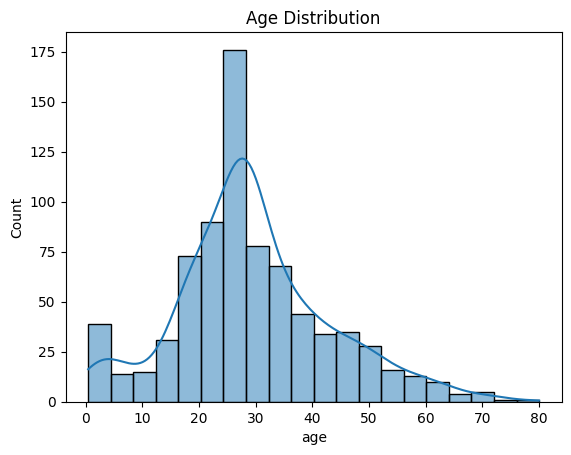

In [13]:
# Exploratory Data Analysis (EDA)

import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of age
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()


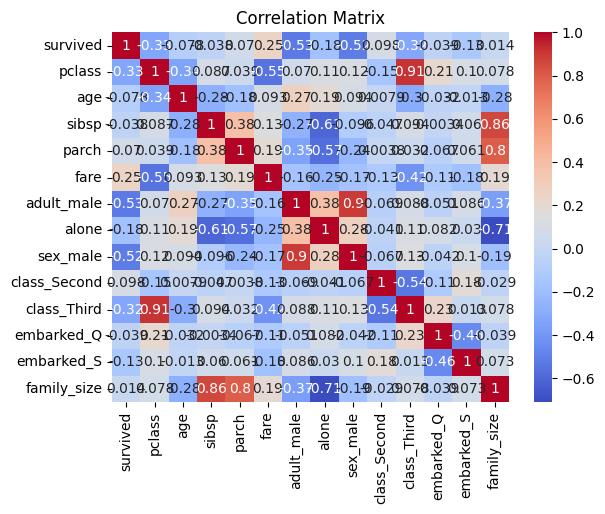

In [14]:
# Correlation matrix
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [15]:
# Step5: Data Modeling

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Define features and target
X = df.drop(columns=['survived'])
y = df['survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [16]:
#  Model Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8193548387096774
Precision: 0.7758620689655172
Recall: 0.75
Confusion Matrix:
 [[82 13]
 [15 45]]
